In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn import preprocessing
import re 
import seaborn as sns

In [2]:
df_admits = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\diagnoses_icd.csv.gz', compression='gzip')
df_transfers = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar.csv.gz', compression='gzip')
#df_medi_details = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar_detail.csv.gz', compression='gzip')


In [3]:
df_admits = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\diagnoses_icd.csv.gz', compression='gzip')
#df_transfers = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar.csv.gz', compression='gzip')
#df_medi_details = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar_detail.csv.gz', compression='gzip')


In [3]:
#print(df_admits.head(10))
#print(df_diagnosis.head(10))
#print(df_icd_proc.head(10))
#print(df_icd_diagnosis.head(10))
df_medi.head(10)

,subject_id,hadm_id,emar_id,emar_seq,poe_id,pharmacy_id,enter_provider_id,charttime,medication,event_txt,scheduletime,storetime
0,10000032,22595853.0,10000032-10,10,10000032-32,86768272.0,NaN,2180-05-07 07:51:00,Heparin,Administered,2180-05-07 08:00:00,2180-05-07 07:56:00
1,10000032,22595853.0,10000032-11,11,10000032-37,43092008.0,NaN,2180-05-07 07:51:00,Raltegravir,Administered,2180-05-07 08:00:00,2180-05-07 07:56:00
2,10000032,22595853.0,10000032-12,12,10000032-27,30740602.0,NaN,2180-05-07 07:51:00,Sodium Chloride 0.9% Flush,Flushed,2180-05-07 07:51:00,2180-05-07 07:56:00
3,10000032,22595853.0,10000032-13,13,10000032-36,NaN,NaN,2180-05-07 08:00:00,Nicotine Patch,Not Applied,2180-05-07 08:00:00,2180-05-07 07:57:00
4,10000032,22595853.0,10000032-14,14,10000032-35,NaN,NaN,2180-05-07 08:00:00,Furosemide,Not Given,2180-05-07 08:00:00,2180-05-07 09:27:00
5,10000032,22595853.0,10000032-15,15,10000032-38,NaN,NaN,2180-05-07 08:00:00,Spironolactone,Not Given,2180-05-07 08:00:00,2180-05-07 09:27:00
6,10000032,22595853.0,10000032-16,16,10000032-42,NaN,NaN,2180-05-07 12:00:00,Ipratropium Bromide Neb,Not Given,2180-05-07 12:00:00,2180-05-07 11:39:00
7,10000032,22595853.0,10000032-17,17,10000032-33,73243129.0,NaN,2180-05-07 11:39:00,Albuterol Inhaler,Administered,2180-05-07 11:39:00,2180-05-07 11:40:00
8,10000032,22595853.0,10000032-18,18,10000032-55,12775705.0,NaN,2180-05-07 11:54:00,Furosemide,Administered,2180-05-07 10:00:00,2180-05-07 11:54:00
9,10000032,22595853.0,10000032-19,19,10000032-56,46308055.0,NaN,2180-05-07 11:54:00,Spironolactone,Administered,2180-05-07 10:00:00,2180-05-07 11:54:00


In [35]:
# Data Checks

#df_admits.isna().any() # check which columns have NaN
df_admits.loc[:,df_admits.isna().any()]
#df_admits[df_admits['admission_location'] == '']
#pd.reset_option('display.max_rows')


,deathtime,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,edregtime,edouttime
0,NaN,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,2180-05-06 19:17:00,2180-05-06 23:30:00
1,NaN,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,2180-06-26 15:54:00,2180-06-26 21:31:00
2,NaN,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,2180-08-05 20:58:00,2180-08-06 01:44:00
3,NaN,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,2180-07-23 05:54:00,2180-07-23 14:00:00
4,NaN,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,2160-03-03 21:55:00,2160-03-04 06:26:00
...,...,...,...,...,...,...,...,...,...
546023,NaN,P13JMH,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,2149-01-08 09:11:00,2149-01-08 18:12:00
546024,NaN,P38XL8,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,2147-07-17 17:18:00,2147-07-18 17:34:00
546025,2164-09-17 13:42:00,P33612,EMERGENCY ROOM,DIED,Private,English,WIDOWED,2164-09-10 11:09:00,2164-09-10 14:46:00
546026,NaN,P036NA,EMERGENCY ROOM,HOME,Private,English,WIDOWED,2164-07-24 21:16:00,2164-07-25 01:20:00


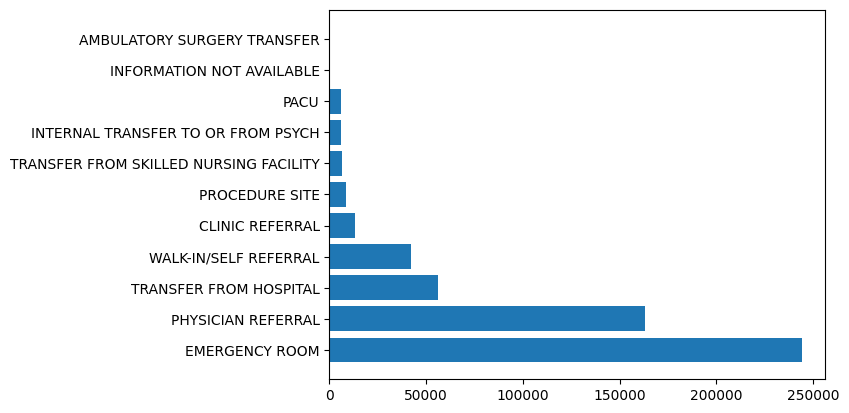

In [6]:
plt.barh(df_admits['admission_location'].value_counts().index,df_admits.admission_location.value_counts().values)
plt.show() # to check for missing values 

In [19]:
# Join diagnosis, admissions and procs
df_admit_icd = pd.merge(df_admits,df_diagnosis,how = 'left', on = 'hadm_id')
df_admit_diagnosis = pd.merge(df_admit_icd,df_icd_diagnosis,how = 'left', on = 'icd_code')
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_icd_proc,how = 'left', on = 'icd_code')


In [20]:
pd.set_option('display.max_columns', None)
df_admit_diagnosis.rename(columns={'long_title_x': 'icd_diagnosis_name','long_title_y':'proc_name'}, inplace=True)
df_admit_diagnosis.head(5)

,subject_id_x,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,subject_id_y,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,1.0,5723,9.0,9.0,Portal hypertension,NaN,NaN
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,2.0,78959,9.0,9.0,Other ascites,NaN,NaN
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,3.0,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,NaN
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,4.0,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,NaN
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,5.0,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus


In [ ]:
# Next stage
# 1 - Group text fields
# 2 - Enocode catgeorical features
# 3 - Assign appointment readimission instance flags

In [117]:
# 1. 
# 
# Check for how many diagnosis that exist - will need to group diagnosis first for easier encoding
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)
pd.reset_option('display.max_rows')

#df_admit_diagnosis.proc_name.value_counts()

In [21]:
#pd.reset_option('display.max_rows')
# Replace all NaN with 'No Diagnosis'
df_admit_diagnosis['icd_diagnosis_name'] = df_admit_diagnosis['icd_diagnosis_name'].fillna('No Diagnosis')
df_admit_diagnosis['proc_name'] = df_admit_diagnosis['proc_name'].fillna('No Procedure')
#df_admit_diagnosis['icd_code'] = df_admit_diagnosis['icd_code'].fillna('0')
df_admit_diagnosis[df_admit_diagnosis['proc_name'].isna()]

,subject_id_x,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,subject_id_y,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name


In [22]:
df_admit_diagnosis['diagnosis_proc'] = df_admit_diagnosis['icd_diagnosis_name'] + ' ' + df_admit_diagnosis['proc_name']
df_admit_diagnosis['diagnosis_proc'] = df_admit_diagnosis['diagnosis_proc'].apply(lambda x: x.lower())
df_admit_diagnosis.head()

,subject_id_x,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,subject_id_y,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,diagnosis_proc
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,1.0,5723,9.0,9.0,Portal hypertension,NaN,No Procedure,portal hypertension no procedure
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,2.0,78959,9.0,9.0,Other ascites,NaN,No Procedure,other ascites no procedure
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,3.0,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,cirrhosis of liver without mention of alcohol ...
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,4.0,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,No Procedure,unspecified viral hepatitis c without hepatic ...
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,5.0,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,"chronic airway obstruction, not elsewhere clas..."


In [81]:
def custom_preprocessor(text):
    text = text.lower()
    text = re.sub(r'\bother\b', '', text)
    text = re.sub(r'\band unspecified\b', '', text)
    text = re.sub(r'\bnot otherwise specified\b', '', text)
    text = re.sub(r'\bprocedure[s]?\b', '', text)
    text = re.sub(r'\boperation[s]?\b', '', text)
    text = re.sub(r'\bnos\b', '', text)
    #text = re.sub(r'\s+', ' ', text).strip()
    return text


In [8]:
# Apply K-means clustering for text columns
# Inital vectorizer step is key for good clustering - add in custom conditions for stop words and removal of common words

vectorizer = TfidfVectorizer(
                            #preprocessor=custom_preprocessor,
                            #stop_words='english', # might not be a good idea to use for only a single column
                            ngram_range=(1, 2),    # combines phrases  
                            max_df=0.95            # removes words in column/document that appear in > 95% of doc
                             )          
#vectorized_words_diagnosis = vectorizer_d.fit_transform(df_admit_diagnosis['icd_diagnosis_name'])
vectorized_words = vectorizer.fit_transform(df_admit_diagnosis['diagnosis_proc'])


In [9]:
svd = TruncatedSVD(n_components=2, random_state=42)
#reduced_data_diagnosis = svd.fit_transform(vectorized_words_diagnosis)
reduced_data = svd.fit_transform(vectorized_words)

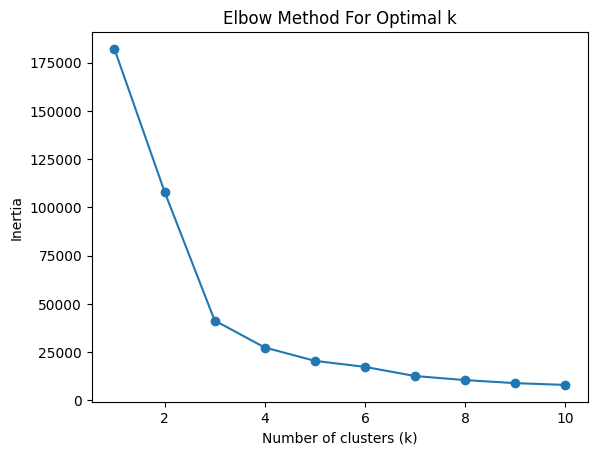

In [10]:
# Use Elbow Method to determine the number of clusters to use

inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(reduced_data)  # use reduced TF-IDF data (from TruncatedSVD)
    inertias.append(kmeans.inertia_)

plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [11]:
num_clusters= 3
kmeans = KMeans(n_clusters=num_clusters, n_init=5, max_iter=500, random_state=42)
kmeans.fit(vectorized_words)

KMeans(max_iter=500, n_clusters=3, n_init=5, random_state=42)

C:\Users\smahmood\AppData\Local\Temp\ipykernel_16252\1442931668.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


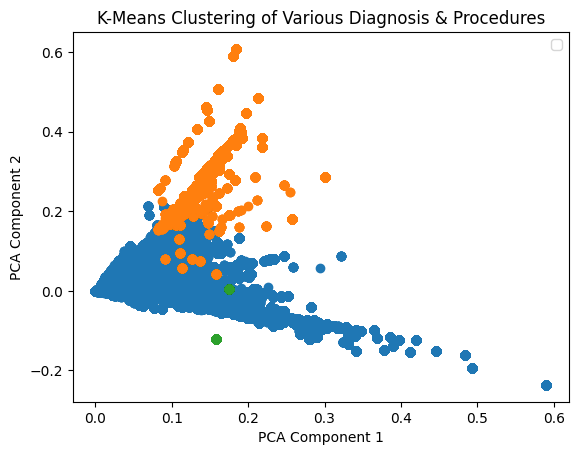

In [12]:
for i in range(num_clusters):
    plt.scatter(reduced_data[kmeans.labels_ == i, 0], 
                reduced_data[kmeans.labels_ == i, 1], 
                )

plt.legend()
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering of Various Diagnosis & Procedures')
plt.show()

In [23]:
df_admit_diagnosis['diagnosis_proc_cluster'] = kmeans.labels_
#add proc cluster here
print(df_admit_diagnosis['diagnosis_proc_cluster'].value_counts())

diagnosis_proc_cluster
0    5692273
1     606343
2     186143
Name: count, dtype: int64


In [24]:
df_admit_diagnosis.head()

,subject_id_x,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,subject_id_y,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,diagnosis_proc,diagnosis_proc_cluster
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,1.0,5723,9.0,9.0,Portal hypertension,NaN,No Procedure,portal hypertension no procedure,0
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,2.0,78959,9.0,9.0,Other ascites,NaN,No Procedure,other ascites no procedure,0
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,3.0,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,cirrhosis of liver without mention of alcohol ...,0
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,4.0,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,No Procedure,unspecified viral hepatitis c without hepatic ...,0
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,5.0,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,"chronic airway obstruction, not elsewhere clas...",0


In [ ]:
df_admit_diagnosis.drop(columns = ['icd_version_y','subject_id_y','icd_version','edregtime','edouttime','deathtime','admit_provider_id','marital_status','hospital_expire_flag',
                                          'seq_num','icd_code','icd_version','language','icd_diagnosis_name','proc_name','diagnosis_proc'],inplace = True)
df_admit_diagnosis.rename(columns={'icd_version_x': 'icd_version','subject_id_x':'subject_id'}, inplace=True)

In [28]:
# Encoding diagnosis table

# combine diagnosis cluster into one admisison per row

df_admit_diagnosis_encoded = pd.get_dummies(df_admit_diagnosis, columns=['diagnosis_proc_cluster'], dtype = int)
df_admit_diagnosis_encoded.head(5)  

,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,1,0,0
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,1,0,0
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,1,0,0
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,1,0,0
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,1,0,0


In [30]:
df_admit_diagnosis_encoded = df_admit_diagnosis_encoded.groupby(['hadm_id', 'subject_id']).agg({
     'admission_type':'first',
     'admission_location': 'first',
     'discharge_location':'first',
     'admittime':'first',
     'dischtime':'first',
     'insurance':'first',
     'race':'first',
     'diagnosis_proc_cluster_0':'sum',
     'diagnosis_proc_cluster_1':'sum',
     'diagnosis_proc_cluster_2':'sum',
     }).reset_index()
df_admit_diagnosis_encoded.head(5)  

,hadm_id,subject_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2
0,20000019,10467237,EW EMER.,EMERGENCY ROOM,HOME,2159-03-20 21:08:00,2159-03-23 16:54:00,Medicaid,HISPANIC/LATINO - GUATEMALAN,10,1,1
1,20000024,16925328,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,2151-05-25 21:44:00,2151-05-26 18:36:00,Medicare,WHITE,8,1,1
2,20000034,19430048,DIRECT OBSERVATION,PHYSICIAN REFERRAL,None,2174-05-22 19:13:00,2174-05-24 17:27:00,Medicare,BLACK/CARIBBEAN ISLAND,23,5,0
3,20000041,18910522,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,2143-09-03 07:15:00,2143-09-06 13:50:00,Private,WHITE,7,2,1
4,20000045,13413708,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,2138-05-21 16:25:00,2138-05-29 02:05:00,Private,WHITE,15,2,0


In [31]:
# Assign admission ranks throughout time
# Readmission is within 30 days of discharge and next admission so insert flag

# USE ADMIT AND DISCH TIME 

df_admit_diagnosis_encoded['admittime'] = pd.to_datetime(df_admit_diagnosis_encoded['admittime'])
df_admit_diagnosis_encoded['dischtime'] = pd.to_datetime(df_admit_diagnosis_encoded['dischtime'])

df_admit_diagnosis_encoded['admission_rank'] = df_admit_diagnosis_encoded.groupby('subject_id')['admittime'].rank(method='dense', ascending=True)
df_admit_diagnosis_encoded.sort_values(by = ['admission_rank'],ascending= True, inplace= True)
# Get next admission's out time for each patient
df_admit_diagnosis_encoded['last_dischtime'] = df_admit_diagnosis_encoded.groupby('subject_id')['dischtime'].shift(1)

# Calculate days until next visit
df_admit_diagnosis_encoded['days_from_last'] = (df_admit_diagnosis_encoded['admittime'] - df_admit_diagnosis_encoded['last_dischtime']).dt.days

# Create readmission flag (1 if last visit is within 30 days, else 0)
df_admit_diagnosis_encoded['readmission'] = df_admit_diagnosis_encoded['days_from_last'].apply(lambda x: 1 if pd.notnull(x) and x <= 30 and x >= 0 else 0)

df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]

,hadm_id,subject_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2,admission_rank,last_dischtime,days_from_last,readmission
141961,22595853,10000032,URGENT,TRANSFER FROM HOSPITAL,HOME,2180-05-06 22:23:00,2180-05-07 17:15:00,Medicaid,WHITE,7,1,0,1.0,NaT,NaN,0
155119,22841357,10000032,EW EMER.,EMERGENCY ROOM,HOME,2180-06-26 18:27:00,2180-06-27 18:49:00,Medicaid,WHITE,8,0,0,2.0,2180-05-07 17:15:00,50.0,0
495453,29079034,10000032,EW EMER.,EMERGENCY ROOM,HOME,2180-07-23 12:35:00,2180-07-25 17:55:00,Medicaid,WHITE,14,0,0,3.0,2180-06-27 18:49:00,25.0,1
313493,25742920,10000032,EW EMER.,EMERGENCY ROOM,HOSPICE,2180-08-05 23:44:00,2180-08-07 17:50:00,Medicaid,WHITE,11,0,0,4.0,2180-07-25 17:55:00,11.0,1


In [ ]:
# label encode the text columns
df_admit_diagnosis_encoded.drop(columns= ['admittime','dischtime','last_dischtime','days_from_last', 'admission_rank'], inplace= True) #' drop irrelevant cols

cols_to_encode = ['admission_type','admission_location','discharge_location','insurance','race','gender']
label_encoder = preprocessing.LabelEncoder()
for col in cols_to_encode:
    df_admit_diagnosis_encoded[col] = label_encoder.fit_transform(df_admit_diagnosis_encoded[col])
df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]


,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2,readmission
141961,22595853,10000032,8,8,6,0,28,7,1,0,0
155119,22841357,10000032,5,2,6,0,28,8,0,0,0
495453,29079034,10000032,5,2,6,0,28,14,0,0,1
313493,25742920,10000032,5,2,8,0,28,11,0,0,1


In [ ]:
# join beforehand
df_admit_diagnosis_encoded = pd.merge(df_admit_diagnosis_encoded,df_pat[['subject_id', 'anchor_age','gender']],how = 'left', on = 'subject_id')
df_admit_diagnosis_encoded.head()

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2,readmission,anchor_age,gender
0,20001596,15327072,4,10,13,3,7,5,1,1,0,65,M
1,20001633,18030855,5,2,6,0,28,7,0,0,0,28,F
2,20001747,12270767,6,8,7,1,28,9,1,0,0,91,F
3,20001770,10117812,5,10,11,0,28,21,1,0,0,35,F
4,20001800,11828074,4,2,13,4,28,5,1,0,0,59,M


In [33]:
# Clean and encode medication table first before joining onto main table

#df_medi[df_medi['hadm_id'].isin(df_admits['hadm_id'])]
df_medi.drop(columns = ['enter_provider_id','charttime','scheduletime','storetime','emar_id','emar_seq','poe_id','pharmacy_id','enter_provider_id'
                        ,'charttime','scheduletime','storetime'], inplace= True)
df_medi['medication'] = df_medi['medication'].fillna('No Medication')
df_medi.head(5)

,subject_id,hadm_id,medication,event_txt
0,10000032,22595853.0,Heparin,Administered
1,10000032,22595853.0,Raltegravir,Administered
2,10000032,22595853.0,Sodium Chloride 0.9% Flush,Flushed
3,10000032,22595853.0,Nicotine Patch,Not Applied
4,10000032,22595853.0,Furosemide,Not Given


In [38]:
df_medi['medication_usage'] = df_medi['medication'] + ' ' + df_medi['event_txt']
df_medi['medication_usage'] = df_medi['medication_usage'].fillna('No Medication')
df_medi.head()

,subject_id,hadm_id,medication,event_txt,medication_usage
0,10000032,22595853.0,Heparin,Administered,Heparin Administered
1,10000032,22595853.0,Raltegravir,Administered,Raltegravir Administered
2,10000032,22595853.0,Sodium Chloride 0.9% Flush,Flushed,Sodium Chloride 0.9% Flush Flushed
3,10000032,22595853.0,Nicotine Patch,Not Applied,Nicotine Patch Not Applied
4,10000032,22595853.0,Furosemide,Not Given,Furosemide Not Given


In [39]:
vectorized_words_medi = vectorizer.fit_transform(df_medi['medication_usage'])
reduced_data_medi = svd.fit_transform(vectorized_words_medi)

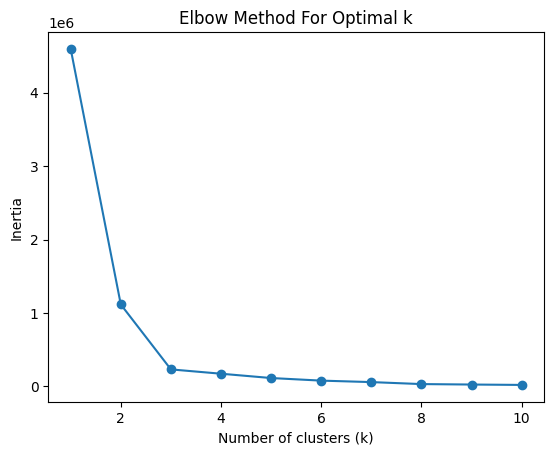

In [40]:
inertias_medi = []
K = range(1, 11)

for k in K:
    kmeans_m = KMeans(n_clusters=k, random_state=42)
    kmeans_m.fit(reduced_data_medi)  # use reduced TF-IDF data (from TruncatedSVD)
    inertias_medi.append(kmeans_m.inertia_)

plt.plot(K, inertias_medi, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [41]:
num_clusters= 3
kmeans_m = KMeans(n_clusters=num_clusters, n_init=5, max_iter=500, random_state=42)
kmeans_m.fit(vectorized_words_medi)

KMeans(max_iter=500, n_clusters=3, n_init=5, random_state=42)

C:\Users\smahmood\AppData\Local\Temp\ipykernel_16252\2819449684.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


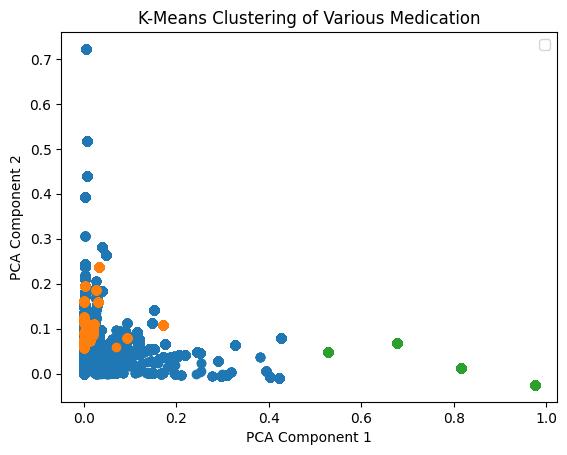

In [42]:
for i in range(num_clusters):
    plt.scatter(reduced_data_medi[kmeans_m.labels_ == i, 0], 
                reduced_data_medi[kmeans_m.labels_ == i, 1], 
                )

plt.legend()
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering of Various Medication')
plt.show()

In [43]:
df_medi['medication_usage_cluster'] = kmeans_m.labels_
#add proc cluster here
print(df_medi['medication_usage_cluster'].value_counts())

medication_usage_cluster
0    34764931
2     4554267
1     3489395
Name: count, dtype: int64


In [59]:
df_medi_encoded = pd.get_dummies(df_medi,columns= ['medication_usage_cluster'],dtype = int)
df_medi_encoded.drop(columns=['medication','event_txt','medication_usage'], inplace= True)

In [60]:
df_medi_encoded = df_medi_encoded.groupby(['hadm_id', 'subject_id']).agg({
'medication_usage_cluster_0':'sum',
'medication_usage_cluster_1':'sum',
'medication_usage_cluster_2':'sum',
}).reset_index()

In [65]:
df_medi_encoded['hadm_id'] = df_medi_encoded['hadm_id'].astype(int)
df_admit_diagnosis_encoded['hadm_id'] = df_admit_diagnosis_encoded['hadm_id'].astype(int)
df_admit_diagnosis_encoded.head()

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2,readmission,anchor_age,gender
0,20001596,15327072,4,10,13,3,7,5,1,1,0,65,1
1,20001633,18030855,5,2,6,0,28,7,0,0,0,28,0
2,20001747,12270767,6,8,7,1,28,9,1,0,0,91,0
3,20001770,10117812,5,10,11,0,28,21,1,0,0,35,0
4,20001800,11828074,4,2,13,4,28,5,1,0,0,59,1


In [66]:
# Merge both encoded tables

df_full_dataset = pd.merge(
    df_admit_diagnosis_encoded,
    df_medi_encoded[['hadm_id', 'medication_usage_cluster_0', 'medication_usage_cluster_1', 'medication_usage_cluster_2']],
    how='left',
    on='hadm_id'
)


In [67]:
df_full_dataset.head()

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2,readmission,anchor_age,gender,medication_usage_cluster_0,medication_usage_cluster_1,medication_usage_cluster_2
0,20001596,15327072,4,10,13,3,7,5,1,1,0,65,1,8.0,0.0,0.0
1,20001633,18030855,5,2,6,0,28,7,0,0,0,28,0,NaN,NaN,NaN
2,20001747,12270767,6,8,7,1,28,9,1,0,0,91,0,51.0,2.0,18.0
3,20001770,10117812,5,10,11,0,28,21,1,0,0,35,0,378.0,11.0,49.0
4,20001800,11828074,4,2,13,4,28,5,1,0,0,59,1,NaN,NaN,NaN


Build Logistic Regression Model

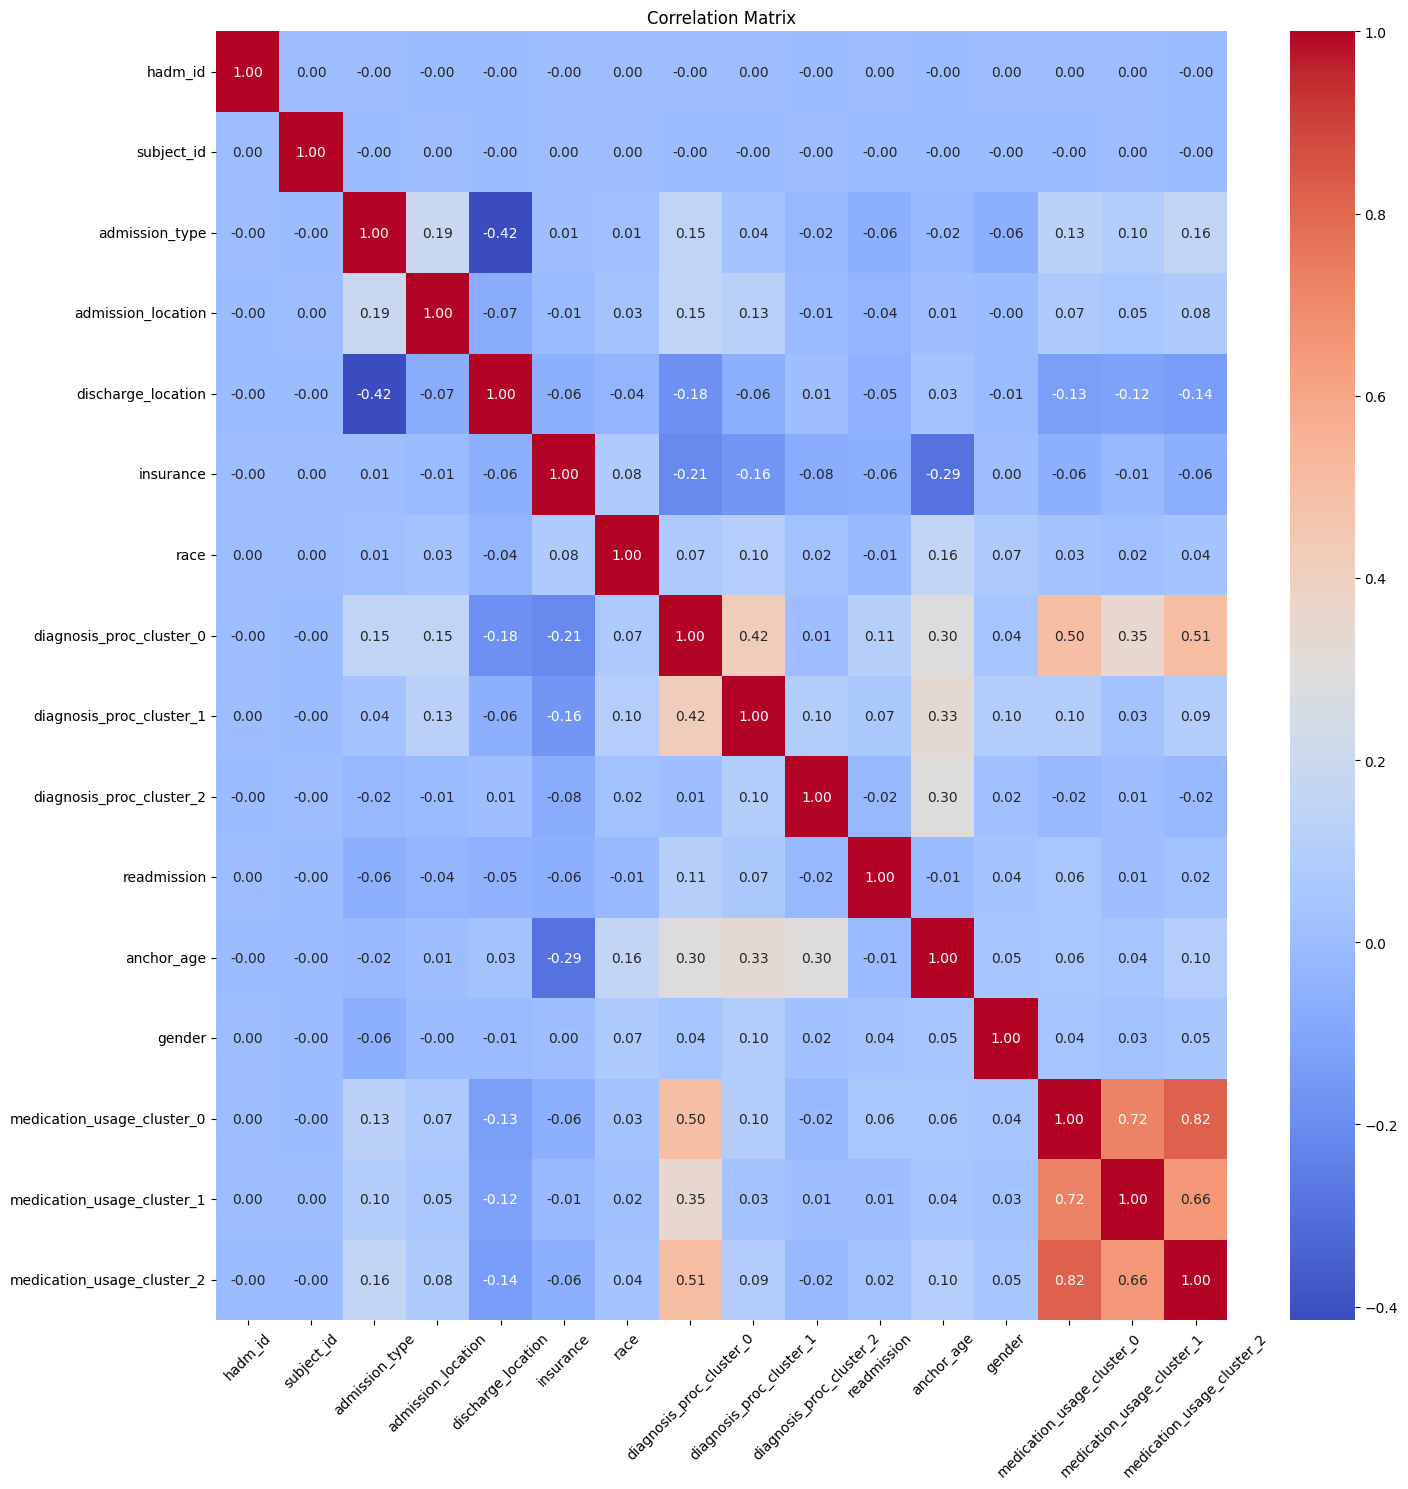

In [74]:
# correlation matrix
corr_matrix = df_full_dataset.corr()

plt.figure(figsize=(15, 15))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()